In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from sklearn.utils import shuffle
from skimage.transform import resize

In [7]:
Beagle= glob.glob(r"C:\Users\STD_Evening\Downloads\img project\dataset\Beagle/*.jpg")
Boxer= glob.glob(r"C:\Users\STD_Evening\Downloads\img project\dataset\Boxer/*.jpg")
Bulldog= glob.glob(r"C:\Users\STD_Evening\Downloads\img project\dataset\Bulldog/*.jpg")

In [8]:
print(len(Beagle))
print(len(Boxer))
print(len(Bulldog))

100
100
100


In [9]:
Beagle[0]

'C:\\Users\\STD_Evening\\Downloads\\img project\\dataset\\Beagle\\Beagle_1.jpg'

In [10]:
plt.imread(Beagle[0])

array([[[  0,   1,   0],
        [  0,   2,   0],
        [  3,   5,   0],
        ...,
        [ 25,  42,  26],
        [ 12,  24,   2],
        [ 14,  26,   4]],

       [[  2,   4,   0],
        [  2,   4,   0],
        [  4,   6,   1],
        ...,
        [ 30,  46,  33],
        [ 21,  33,  13],
        [ 26,  38,  18]],

       [[  7,   9,   4],
        [  5,   7,   2],
        [  5,   7,   2],
        ...,
        [ 32,  48,  35],
        [ 22,  33,  17],
        [ 30,  41,  25]],

       ...,

       [[148, 121, 110],
        [149, 122, 111],
        [151, 124, 113],
        ...,
        [145, 123, 110],
        [146, 124, 111],
        [146, 124, 111]],

       [[147, 120, 109],
        [148, 121, 110],
        [150, 123, 112],
        ...,
        [144, 122, 109],
        [145, 123, 110],
        [145, 123, 110]],

       [[145, 118, 107],
        [146, 119, 108],
        [148, 121, 110],
        ...,
        [142, 120, 107],
        [144, 122, 109],
        [144, 122, 109]]

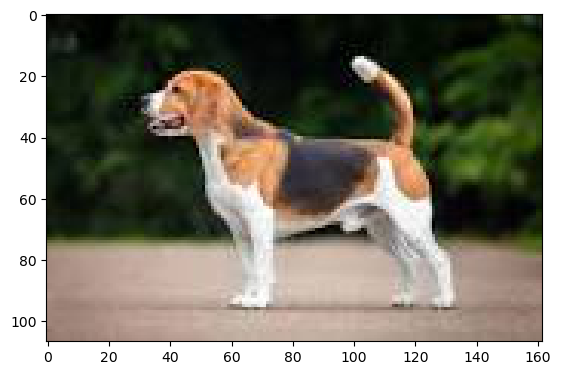

In [11]:
plt.imshow(plt.imread(Beagle[0]))

In [12]:
image = []
label = []

for i in Beagle:
    img=plt.imread(i)
    image.append(img)
    label.append(0)


for i in Boxer:
    img=plt.imread(i)
    image.append(img)
    label.append(1)


for i in Bulldog:
    img=plt.imread(i)
    image.append(img)
    label.append(2)

In [14]:
label_names={0:"Beagle", 1:"Boxer", 2:"Bulldog"}

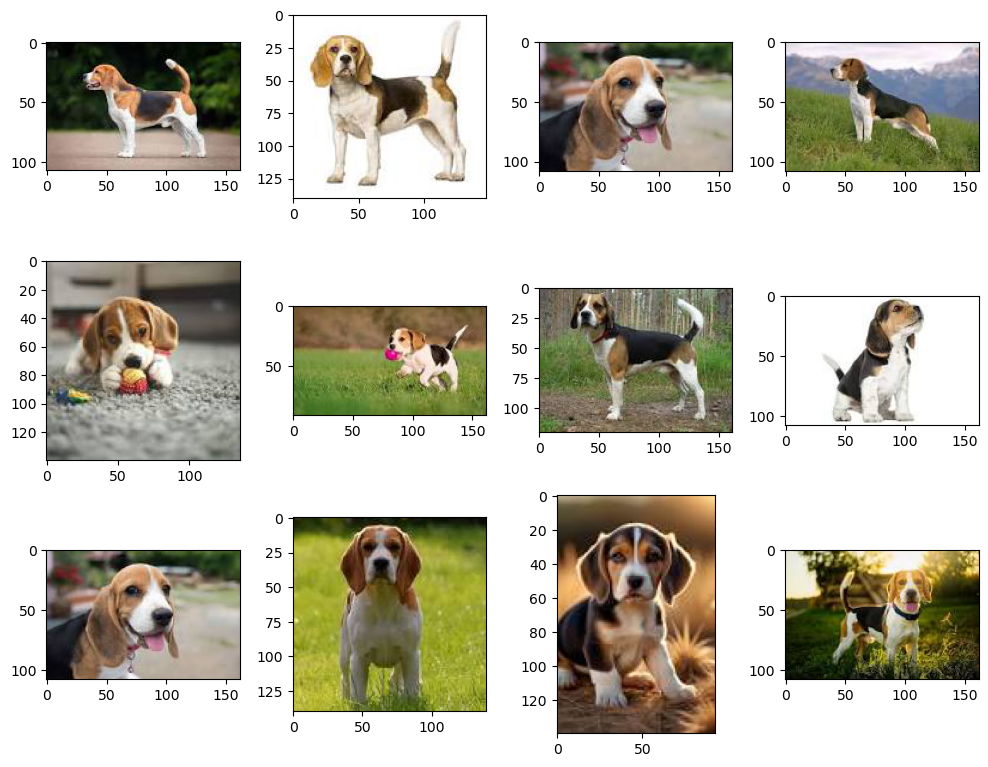

In [15]:
plt.figure(figsize = (10,8))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(image[i])
plt.tight_layout()

In [16]:
image, label= shuffle(image, label)

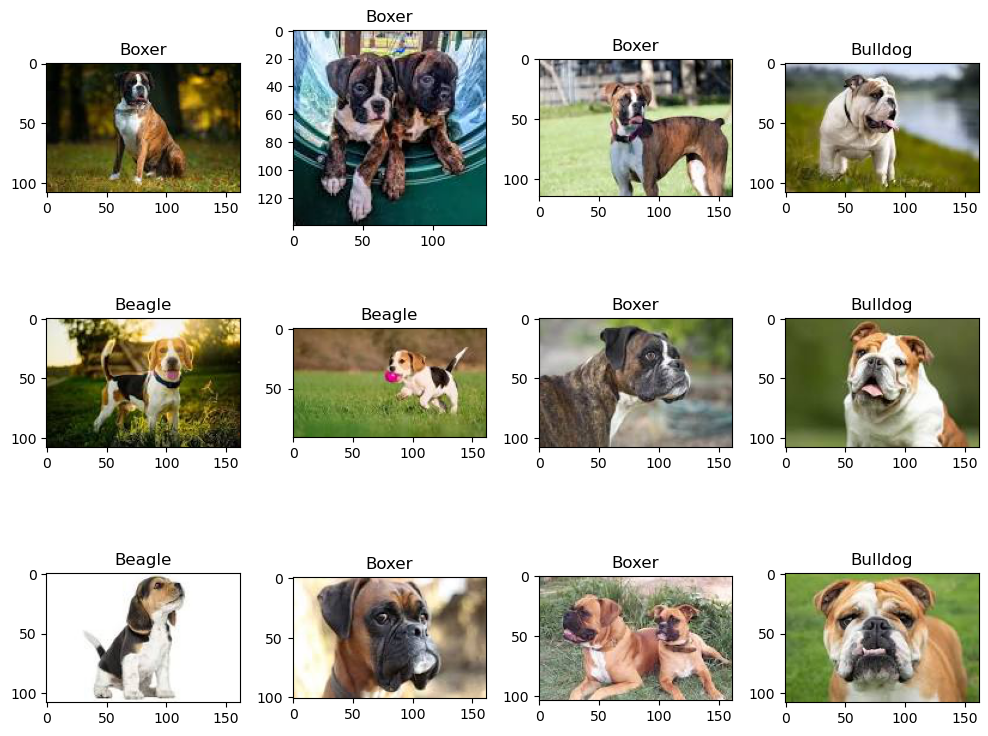

In [17]:
plt.figure(figsize = (10,8))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(image[i])
    plt.title(label_names[label[i]])
plt.tight_layout()

In [18]:
for i in range(12):
    print(image[i].shape)

(108, 162, 3)
(140, 139, 3)
(115, 162, 3)
(108, 162, 3)
(108, 162, 3)
(91, 162, 3)
(108, 162, 3)
(108, 162, 3)
(108, 162, 3)
(101, 162, 3)
(104, 162, 3)
(108, 162, 3)


In [19]:
x= []

for i in image:
    x.append(resize(i,(600,600,3)))

In [20]:
x= np.array(x)
y=np.array(label)

In [21]:
d1, d2, d3, d4= x.shape
x= x.reshape((d1,d2*d3*d4))

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2)

In [24]:
from sklearn.svm import SVC

In [25]:
model = SVC()

In [27]:
%time model.fit(x_train, y_train)

CPU times: total: 2min 55s
Wall time: 1min 19s


SVC()

In [29]:
%time y_pred = model.predict(x_test)

CPU times: total: 5min 7s
Wall time: 1min 23s


In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [31]:
accuracy_score(y_test,y_pred)

1.0

<Axes: >

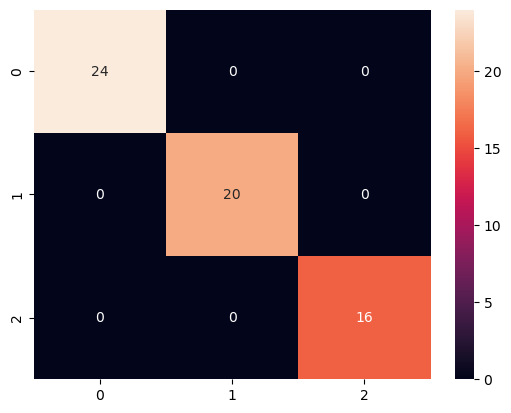

In [32]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot = True)

In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        16

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

